In [1]:
import numpy as np
import cv2
import skimage.morphology as skm
import matplotlib.pyplot as plt
from skimage import measure, color

def image_segmentation(path_img, size_img, display_results = True):
    #================================================================
    # Read the image and convert it to gray scale

    img = path_img
    gray_img = cv2.cvtColor(img,cv2.COLOR_BGR2GRAY)

    #================================================================
    # Preprocessing of the image

    # sharpen operation 
    kernel_pre1 = np.array([[0, -1, 0],[-1, 5, -1],[0, -1, 0]])
    #kernel_pre1 = np.array([[-1, -1, -1, -1, -1],[-1, -1, -1, -1, -1],[-1, -1, 27, -1, -1], [-1, -1, -1, -1, -1], [-1, -1, -1, -1, -1]])
    #kernel_pre = np.array([[-1, -1, -1], [-1, 9, -1], [-1, -1, -1]])
    img_sharpen = cv2.filter2D(gray_img,-1,kernel_pre1)

    # gaussien blur operation 
    kernel_pre2 = np.array([[1, 4, 6, 4, 1],[4, 16, 24, 16, 4],[6, 24, 36, 24, 6], [4, 16, 24, 16, 4], [1, 4, 6, 4, 1]])/256  
    img_blur = cv2.filter2D(img_sharpen,-1,kernel_pre2)
    #img_smooth = cv2.medianBlur(img_sharpen,3)

    #================================================================
    # edges extraction based on the adaptive treshold

    img_AT_1 = cv2.adaptiveThreshold(img_blur, 255, cv2.ADAPTIVE_THRESH_GAUSSIAN_C, cv2.THRESH_BINARY, 9, 3)
    closing1 = skm.area_closing(img_AT_1, area_threshold=15, connectivity=1)

    #================================================================
    # Extraction of sure forground using distance transform, treshold and opening algorithms

    # distance transform allow more controle than erosion
    dist_transform = cv2.distanceTransform(closing1,cv2.DIST_L2,3)
    ret1, sure_fg1 = cv2.threshold(dist_transform, 0.1*dist_transform.max(), 255, cv2.THRESH_BINARY)

    kernel = np.ones((3,3),np.uint8)
    opening = cv2.morphologyEx(sure_fg1, cv2.MORPH_OPEN, kernel, iterations = 1)
    sure_fg2 = opening.astype(np.uint8)

    #================================================================
    # Creating background image (white image all value == 255)
    # we don't need to use dilation because in our case we dont have a background 

    sure_bg = np.full(size_img, 255, np.uint8)
    #kernel = np.ones((3,3),np.uint8)
    #sure_bg = cv2.dilate(sure_fg2, kernel, iterations = 100)

    #================================================================
    # Finding unknown region

    unknown1 = cv2.subtract(sure_bg,sure_fg2)

    #================================================================
    # preparing markers

    # Marker labelling
    ret1, markers1 = cv2.connectedComponents(sure_fg2)
    # Add one to all labels so that sure background is not 0, but 1
    markers1 = markers1 + 1
    # Now, mark the region of unknown with zero
    markers1[unknown1==255] = 0

    #================================================================
    # apply watershed algorithm

    markers1 = cv2.watershed(img,markers1)
    markers1_img = markers1.astype(np.uint8)
    markers1b = color.label2rgb(markers1, bg_label=0)

    #================================================================
    
    
    if display_results == True:
        img1 = np.copy(img)
        img1[markers1 == -1] = [0,0,255]
        cv2.imshow("img1",img1)
        cv2.imshow("gray_img",gray_img)
        cv2.imshow("img_sharpen",img_sharpen)
        cv2.imshow("img_blur",img_blur)
        cv2.imshow("img_AT_1",img_AT_1)
        cv2.imshow("closin1",closing1)
        cv2.imshow("sure_fg1",sure_fg1)
        cv2.imshow("opening",opening)
        cv2.imshow("sure_fg2",sure_fg2)
        cv2.imshow("sure_bg",sure_bg)
        cv2.imshow("markers1_img",markers1_img)


    cv2.waitKey(0) 
    cv2.destroyAllWindows()
    
    return markers1, gray_img

In [2]:
def bubble_size_measurements(markers, gray_img, list_max_group_perimeters, list_max_group_areas, pixels_to_mm):
    ### this function arrange perimeters and areas into groups and returns :
        # the total number of bubbles in an image
        # a list of percentage of number of items in each group 
        # a average perimeter and the average area in each group
    
    regions = measure.regionprops(markers, intensity_image=gray_img)
    pixels_to_mm = 1 # Determine how many pixels are in each mm
    perimeters_list = []
    areas_list = []

    for region in regions:
        perimeters_list.append(region['perimeter'] * pixels_to_mm)
        areas_list.append(region['area'] * pixels_to_mm**2)
        
    # Calculate the total number of bubbles 
    total_number = len(regions)
    
    # Creat groupes of perimeters and areas
    list_groups_perimeters = []
    list_groups_areas = []
    for i in range(len(list_max_group_perimeters) + 1):
        list_groups_perimeters.append([])
        list_groups_areas.append([])
    
    # Arrange perimeters and areas into groups
    for (perimeter, area) in zip(perimeters_list, areas_list):
        i = 0 # the index of a groupe of perimeters in list_groups_perimeters (same with areas)
        perimeter_appended = False
        area_appended = False
        for (max_group_perimeters, max_group_areas) in zip(list_max_group_perimeters, list_max_group_areas):
            if perimeter <= max_group_perimeters and perimeter_appended == False:
                list_groups_perimeters[i].append(perimeter)
                perimeter_appended = True
                
            if area <= max_group_areas and area_appended == False:
                list_groups_areas[i].append(area)
                area_appended = True
                
            i = i+1 # we pass to the next groupe of perimeters or areas
        
        # for the last groupe    
        if perimeter > list_max_group_perimeters[i-1] and perimeter_appended == False:
                list_groups_perimeters[i].append(perimeter)
                perimeter_appended = True
                
        if area > list_max_group_areas[i-1] and area_appended == False:
            list_groups_areas[i].append(area)
            area_appended = True
            
    # Calculate the percentage and the average for each group
    list_percentages = []
    list_averages = []
    for (group_p, group_a) in zip(list_groups_perimeters, list_groups_areas):
        
        ####################################################################
        # Calculate the percentage of number of items in each group
        ####################################################################
        percentage = {}
        
        ### for the group of perimeters
        if group_p: # if the list group_p is not empty
            p = len(group_p) # / total_number
            # p = p*100
            percentage["perimeters"] = p
        else :
            percentage["perimeters"] = 0
            
        ### for the group of areas
        if group_a: # if the list group_p is not empty
            p = len(group_a) #/ total_number
            # p = p*100
            percentage["areas"] = p
        else :
            percentage["areas"] = 0
            
        list_percentages.append(percentage)
        
        
    return total_number, list_percentages
                

In [3]:
def bubble_size_distribution(path_img, size_img, list_max_group_perimeters, list_max_group_areas, pixels_to_mm, display_results = True):
    # segment the image
    markers, gray_img = image_segmentation(path_img, size_img, display_results)
    # extract bubble size measurements
    total_number, list_percentages = bubble_size_measurements(markers, gray_img, list_max_group_perimeters, list_max_group_areas, pixels_to_mm)
    
    return total_number, list_percentages

# First Video

In [14]:
# read the video 

cap = cv2.VideoCapture('rl4_pb17-4.mp4')

cap.set(cv2.CAP_PROP_POS_MSEC, 7500)
ret, frame = cap.read()

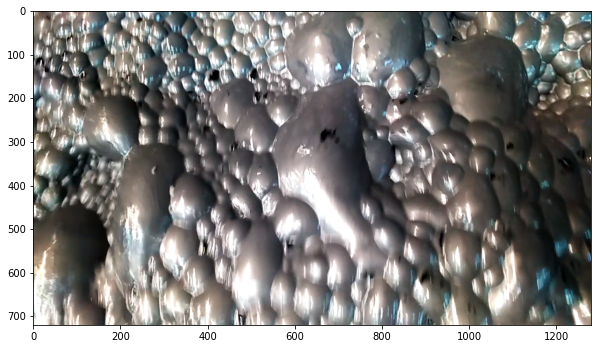

In [15]:
# Plot the frame using matplotlib
plt.figure(figsize=(10,10))
plt.imshow(frame)
plt.show()


In [16]:


path_img = './dep_img/rl3_pb17-4-1.jpg'
size_img = (frame.shape[0], frame.shape[1])
list_max_group_perimeters = [100, 300, 500]
list_max_group_areas = [500, 1000, 2000]
pixels_to_mm = 1

total_number, list_percentages = bubble_size_distribution(frame, size_img, list_max_group_perimeters, list_max_group_areas, pixels_to_mm, display_results = True)
# if display_results == True the function will display the images results in each step of segmentation 

print(total_number)


223


In [18]:
list_percentages

[{'perimeters': 40, 'areas': 57},
 {'perimeters': 118, 'areas': 36},
 {'perimeters': 38, 'areas': 51},
 {'perimeters': 27, 'areas': 79}]

In [19]:
# read the video 

cap = cv2.VideoCapture('rl4_pb17-4.mp4')

cap.set(cv2.CAP_PROP_POS_MSEC, 7700)
ret, frame = cap.read()

path_img = './dep_img/rl3_pb17-4-1.jpg'
size_img = (frame.shape[0], frame.shape[1])
list_max_group_perimeters = [100, 300, 500]
list_max_group_areas = [500, 1000, 2000]
pixels_to_mm = 1

total_number, list_percentages = bubble_size_distribution(frame, size_img, list_max_group_perimeters, list_max_group_areas, pixels_to_mm, display_results = True)
# if display_results == True the function will display the images results in each step of segmentation 

print(total_number)
#print(list_percentages)
#print(list_averages)

277


In [20]:
list_percentages

[{'perimeters': 62, 'areas': 73},
 {'perimeters': 129, 'areas': 51},
 {'perimeters': 56, 'areas': 56},
 {'perimeters': 30, 'areas': 97}]

In [5]:
# read the video

cap = cv2.VideoCapture('rl4_pb17-4.mp4')

# getting the frame rate
fps = cap.get(cv2.CAP_PROP_FPS)

print(f"video fps: {fps}")

# getting the frame count
frame_count = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))

print(f"video frame count: {frame_count}")


video fps: 29.703158414733778
video frame count: 938


In [6]:
round(frame_count/4)

234

In [7]:
# frame resolution
frame_width = int(cap.get(3))
frame_height = int(cap.get(4))

print(f"video frame resolution: {frame_width} x {frame_height}")

video frame resolution: 1280 x 720


In [10]:
%%time
list_max_group_perimeters = [100, 300, 500]
list_max_group_areas = [500, 1000, 2000]
pixels_to_mm = 1

Bubble_number_list = []
groups_list = []
size_img = (frame_height, frame_width)
for i in range(0, round(frame_count/4)):
    cap.set(cv2.CAP_PROP_POS_FRAMES, i)
    ret, frame = cap.read()
    if ret:
        total_number, list_percentages = bubble_size_distribution(frame, size_img, list_max_group_perimeters, list_max_group_areas, pixels_to_mm, display_results = False)
        Bubble_number_list.append(total_number)
        groups_list.append(list_percentages)
    else:
        print(f"frame {i} is not read")

CPU times: total: 2min 55s
Wall time: 6min 21s


In [11]:
print(Bubble_number_list)

[511, 572, 511, 625, 586, 431, 489, 434, 427, 380, 320, 343, 336, 268, 363, 299, 302, 343, 331, 215, 224, 284, 280, 213, 295, 231, 308, 214, 184, 247, 278, 243, 208, 172, 178, 209, 238, 256, 222, 240, 211, 169, 182, 199, 255, 270, 294, 245, 322, 311, 385, 428, 434, 375, 348, 308, 365, 389, 406, 443, 454, 452, 432, 415, 596, 598, 444, 436, 425, 384, 371, 370, 364, 297, 233, 239, 247, 284, 290, 348, 344, 321, 404, 371, 310, 414, 535, 417, 361, 414, 389, 405, 302, 394, 413, 376, 437, 339, 345, 344, 407, 360, 403, 259, 189, 275, 187, 242, 257, 281, 553, 300, 290, 291, 232, 179, 308, 318, 302, 314, 335, 321, 308, 317, 311, 304, 303, 309, 294, 292, 306, 287, 235, 243, 231, 242, 258, 238, 258, 264, 262, 259, 294, 295, 375, 399, 426, 419, 359, 280, 255, 338, 372, 334, 313, 327, 267, 256, 249, 289, 279, 328, 322, 235, 334, 297, 303, 460, 461, 443, 373, 522, 511, 512, 502, 485, 481, 457, 418, 415, 482, 453, 434, 431, 349, 316, 315, 272, 321, 324, 271, 294, 256, 266, 336, 322, 313, 319, 343, 422,

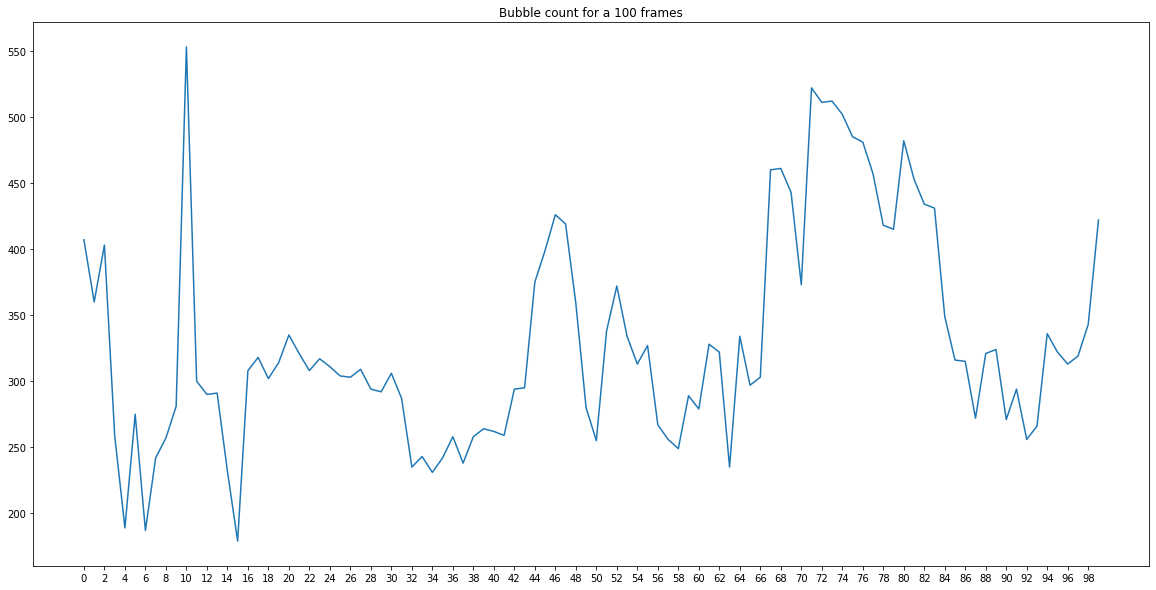

In [12]:
plt.figure(figsize=(20,10))
plt.plot(Bubble_number_list[100:200])
plt.title('Bubble count for a 100 frames')
x = np.arange(0, 100, 2)
plt.xticks(x)
plt.show()


In [33]:
# get frames number 125 and 126 and 127 and plot them
frame125 = cap.set(cv2.CAP_PROP_POS_FRAMES, 109)
ret, frame125 = cap.read()
frame126 = cap.set(cv2.CAP_PROP_POS_FRAMES, 110)
ret, frame126 = cap.read()
frame143 = cap.set(cv2.CAP_PROP_POS_FRAMES, 143)
ret, frame143 = cap.read()
frame144 = cap.set(cv2.CAP_PROP_POS_FRAMES, 144)
ret, frame144 = cap.read()
frame166 = cap.set(cv2.CAP_PROP_POS_FRAMES, 166)
ret, frame166 = cap.read()
frame167 = cap.set(cv2.CAP_PROP_POS_FRAMES, 167)
ret, frame167 = cap.read()


total_number125, list_percentages125 = bubble_size_distribution(frame125, size_img, list_max_group_perimeters, list_max_group_areas, pixels_to_mm, display_results = True)
total_number126, list_percentages126 = bubble_size_distribution(frame126, size_img, list_max_group_perimeters, list_max_group_areas, pixels_to_mm, display_results = True)


In [34]:
total_number143, list_percentages143 = bubble_size_distribution(frame143, size_img, list_max_group_perimeters, list_max_group_areas, pixels_to_mm, display_results = True)
total_number144, list_percentages144 = bubble_size_distribution(frame144, size_img, list_max_group_perimeters, list_max_group_areas, pixels_to_mm, display_results = True)

In [35]:
total_number166, list_percentages166 = bubble_size_distribution(frame166, size_img, list_max_group_perimeters, list_max_group_areas, pixels_to_mm, display_results = True)
total_number167, list_percentages167 = bubble_size_distribution(frame167, size_img, list_max_group_perimeters, list_max_group_areas, pixels_to_mm, display_results = True)

In [36]:
(total_number125,total_number126), (total_number143,total_number144), (total_number166,total_number167)

((281, 553), (295, 375), (303, 460))

In [37]:
import pandas as pd
# perimeter list to dataframe
df_perimeters = pd.DataFrame(groups_list)

# rename the columns of the dataframe
df_perimeters.rename(columns={0: "Group1", 1: "Group2", 2: "Group3", 3: "Group4", }, inplace=True)

df_perimeters

,Group1,Group2,Group3,Group4
0,"{'perimeters': 125, 'areas': 166}","{'perimeters': 288, 'areas': 116}","{'perimeters': 67, 'areas': 113}","{'perimeters': 31, 'areas': 116}"
1,"{'perimeters': 193, 'areas': 243}","{'perimeters': 287, 'areas': 108}","{'perimeters': 58, 'areas': 120}","{'perimeters': 34, 'areas': 101}"
2,"{'perimeters': 137, 'areas': 191}","{'perimeters': 280, 'areas': 115}","{'perimeters': 61, 'areas': 90}","{'perimeters': 33, 'areas': 115}"
3,"{'perimeters': 248, 'areas': 306}","{'perimeters': 299, 'areas': 123}","{'perimeters': 43, 'areas': 110}","{'perimeters': 35, 'areas': 86}"
4,"{'perimeters': 225, 'areas': 271}","{'perimeters': 281, 'areas': 129}","{'perimeters': 54, 'areas': 94}","{'perimeters': 26, 'areas': 92}"
...,...,...,...,...
229,"{'perimeters': 62, 'areas': 73}","{'perimeters': 129, 'areas': 51}","{'perimeters': 56, 'areas': 56}","{'perimeters': 30, 'areas': 97}"
230,"{'perimeters': 43, 'areas': 50}","{'perimeters': 121, 'areas': 45}","{'perimeters': 50, 'areas': 55}","{'perimeters': 34, 'areas': 98}"
231,"{'perimeters': 49, 'areas': 63}","{'perimeters': 121, 'areas': 38}","{'perimeters': 49, 'areas': 57}","{'perimeters': 33, 'areas': 94}"
232,"{'perimeters': 40, 'areas': 54}","{'perimeters': 130, 'areas': 41}","{'perimeters': 46, 'areas': 65}","{'perimeters': 33, 'areas': 89}"


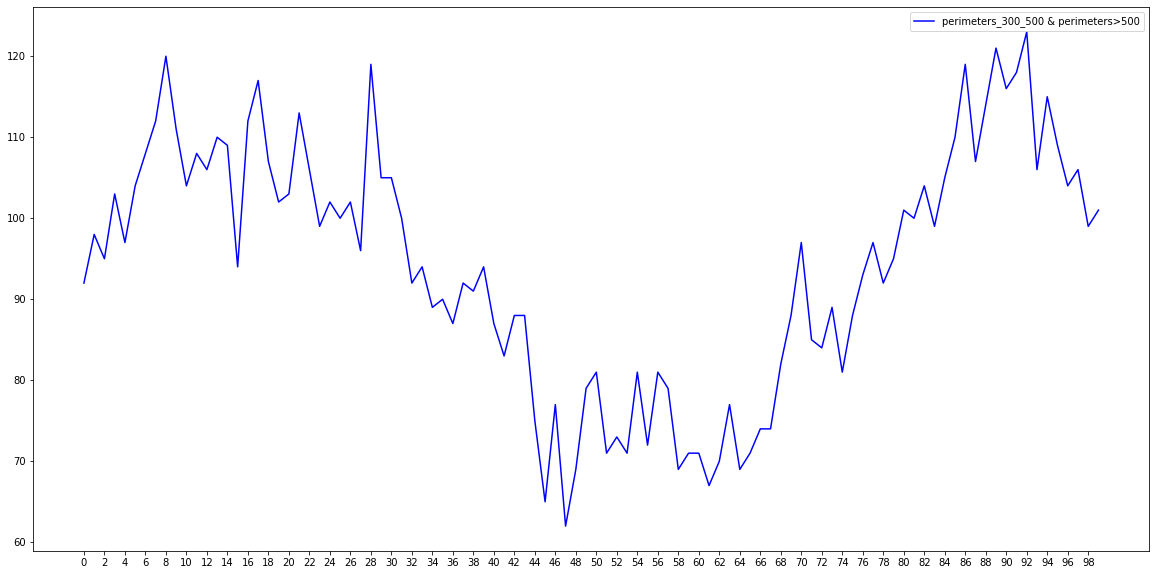

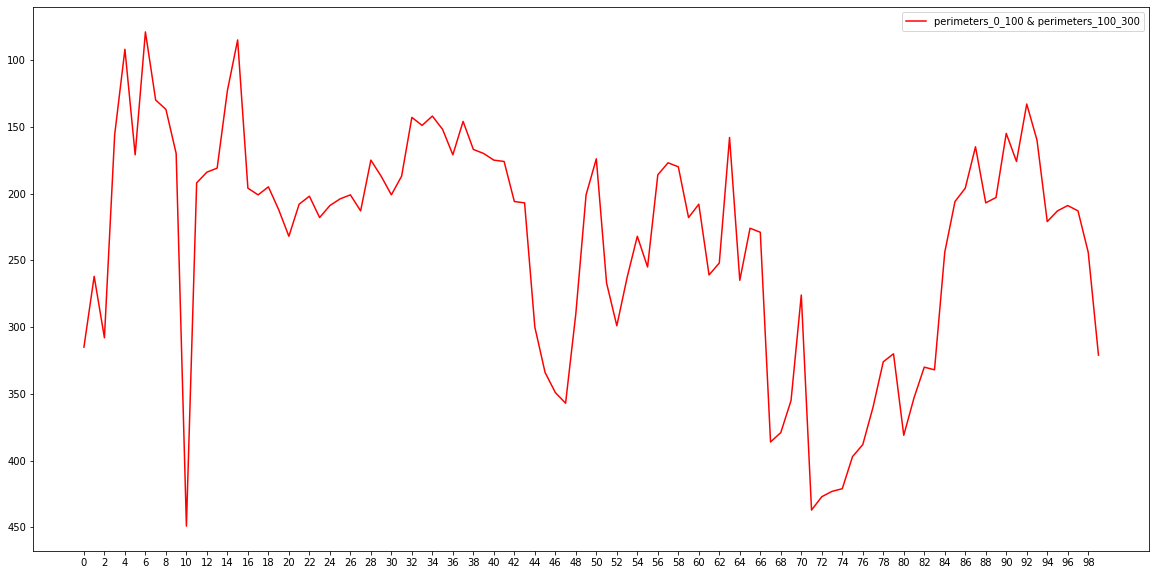

In [38]:
values_big = []
# plot perimeters>500 
for row1,row2 in zip(df_perimeters['Group3'],df_perimeters['Group4']):
    values_big.append(row1['perimeters'] + row2['perimeters'])
plt.figure(figsize=(20,10))
plt.xticks(np.arange(0, 100, 2))
plt.plot(values_big[100:200], color='blue')
plt.legend(['perimeters_300_500 & perimeters>500'])
plt.show()

velues_small = []
# plot perimeters_0_100
for row1 , row2 in zip(df_perimeters['Group1'],df_perimeters['Group2']):
    velues_small.append(row1['perimeters'] + row2['perimeters'])

plt.figure(figsize=(20,10))
# flip the y axis
plt.gca().invert_yaxis()
plt.xticks(np.arange(0, 100, 2))
plt.plot(velues_small[100:200], color='red')
plt.legend(['perimeters_0_100 & perimeters_100_300'])
plt.show()


In [41]:
# get frames number 109 and 110
frame109 = cap.set(cv2.CAP_PROP_POS_FRAMES, 109)
ret, frame109 = cap.read()
frame110 = cap.set(cv2.CAP_PROP_POS_FRAMES, 110)
ret, frame110 = cap.read()

total_number109, list_percentages109 = bubble_size_distribution(frame109, size_img, list_max_group_perimeters, list_max_group_areas, pixels_to_mm, display_results = True)
total_number110, list_percentages110 = bubble_size_distribution(frame110, size_img, list_max_group_perimeters, list_max_group_areas, pixels_to_mm, display_results = True)

In [42]:
(list_percentages109, list_percentages110)

([{'perimeters': 40, 'areas': 60},
  {'perimeters': 130, 'areas': 45},
  {'perimeters': 57, 'areas': 58},
  {'perimeters': 54, 'areas': 118}],
 [{'perimeters': 178, 'areas': 244},
  {'perimeters': 271, 'areas': 119},
  {'perimeters': 69, 'areas': 94},
  {'perimeters': 35, 'areas': 96}])

In [43]:
# frames 166 and 167
frame166 = cap.set(cv2.CAP_PROP_POS_FRAMES, 166)
ret, frame166 = cap.read()
frame167 = cap.set(cv2.CAP_PROP_POS_FRAMES, 167)
ret, frame167 = cap.read()

total_number166, list_percentages166 = bubble_size_distribution(frame166, size_img, list_max_group_perimeters, list_max_group_areas, pixels_to_mm, display_results = True)
total_number167, list_percentages167 = bubble_size_distribution(frame167, size_img, list_max_group_perimeters, list_max_group_areas, pixels_to_mm, display_results = True)

In [44]:
(list_percentages166, list_percentages167)

([{'perimeters': 49, 'areas': 68},
  {'perimeters': 180, 'areas': 63},
  {'perimeters': 44, 'areas': 76},
  {'perimeters': 30, 'areas': 96}],
 [{'perimeters': 136, 'areas': 169},
  {'perimeters': 250, 'areas': 112},
  {'perimeters': 46, 'areas': 100},
  {'perimeters': 28, 'areas': 79}])

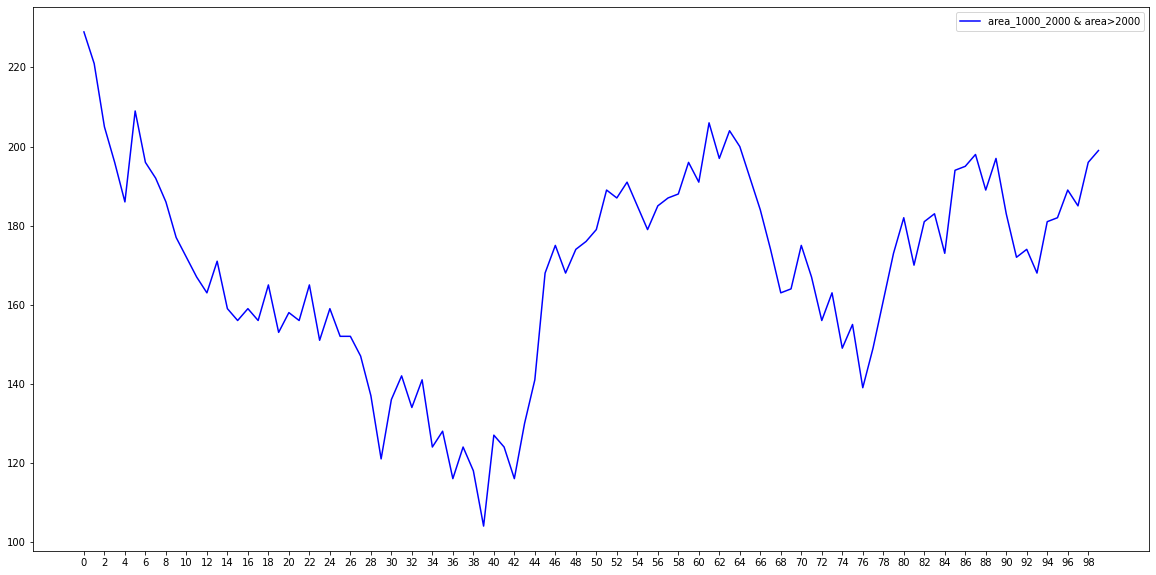

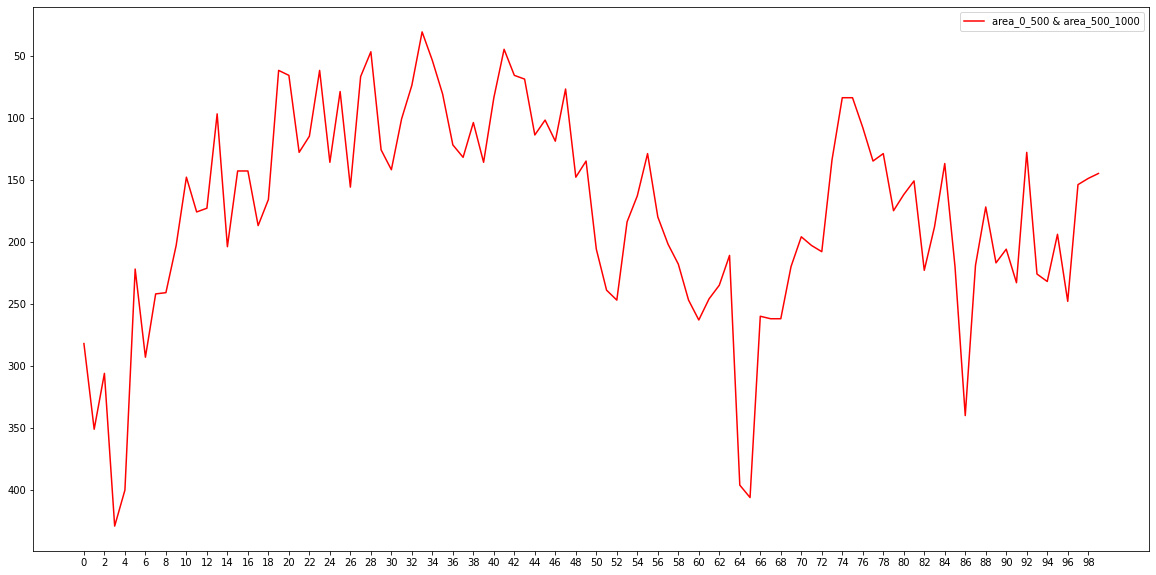

In [39]:
import matplotlib.pyplot as plt

values_big = []
# plot perimeters>500 
for row1,row2 in zip(df_perimeters['Group3'],df_perimeters['Group4']):
    values_big.append(row1['areas'] + row2['areas'])
plt.figure(figsize=(20,10))
plt.xticks(np.arange(0, 100, 2))
plt.plot(values_big[:100], color='blue')
plt.legend(['area_1000_2000 & area>2000'])
plt.show()

velues_small = []
# plot perimeters_0_100
for row1 , row2 in zip(df_perimeters['Group1'],df_perimeters['Group2']):
    velues_small.append(row1['areas'] + row2['areas'])

plt.figure(figsize=(20,10))
# flip the y axis
plt.gca().invert_yaxis()
plt.xticks(np.arange(0, 100, 2))
plt.plot(velues_small[:100], color='red')
plt.legend(['area_0_500 & area_500_1000'])
plt.show()

# Second Video

In [10]:
# Read the video
cap = cv2.VideoCapture('rl4_pb8-7.mp4')

# getting the frame rate
fps = cap.get(cv2.CAP_PROP_FPS)

print(f"video fps: {fps}")

list_max_group_perimeters = [100, 300, 500]
list_max_group_areas = [500, 1000, 2000]
pixels_to_mm = 1

# getting the frame count
frame_count = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))

print(f"video frame count: {frame_count}")

video fps: 29.95603334971612
video frame count: 898


In [11]:
round(frame_count/4)

224

In [12]:
# frame resolution
frame_width = int(cap.get(3))
frame_height = int(cap.get(4))

print(f"video frame resolution: {frame_width} x {frame_height}")

video frame resolution: 1088 x 1088


In [48]:
%%time
list_max_group_perimeters = [100, 300, 500]
list_max_group_areas = [500, 1000, 2000]
pixels_to_mm = 1

Bubble_number_list = []
groups_list = []
size_img = (frame_height, frame_width)
for i in range(0, round(frame_count/4)):
    cap.set(cv2.CAP_PROP_POS_FRAMES, i)
    ret, frame = cap.read()
    if ret:
        total_number, list_percentages = bubble_size_distribution(frame, size_img, list_max_group_perimeters, list_max_group_areas, pixels_to_mm, display_results = False)
        Bubble_number_list.append(total_number)
        groups_list.append(list_percentages)
    else:
        print(f"frame {i} is not read")

CPU times: total: 4min 3s
Wall time: 7min 49s


In [49]:
print(Bubble_number_list)

[1522, 1152, 1145, 1091, 803, 742, 645, 720, 718, 640, 626, 624, 527, 536, 501, 544, 626, 641, 621, 591, 429, 483, 754, 774, 729, 785, 828, 802, 680, 734, 866, 1006, 1041, 697, 759, 427, 450, 337, 449, 413, 405, 449, 442, 453, 479, 512, 496, 600, 496, 600, 563, 640, 552, 482, 538, 502, 562, 527, 640, 675, 702, 661, 715, 586, 508, 671, 576, 698, 869, 757, 879, 758, 673, 693, 526, 684, 657, 653, 622, 637, 726, 773, 913, 988, 829, 972, 690, 649, 763, 488, 520, 501, 590, 469, 502, 539, 602, 675, 648, 650, 649, 645, 571, 588, 476, 533, 625, 686, 547, 648, 690, 703, 1008, 573, 548, 838, 654, 1056, 795, 640, 823, 716, 692, 695, 698, 648, 789, 1058, 822, 994, 800, 929, 1111, 1064, 1024, 1016, 1152, 1088, 1062, 1035, 684, 777, 752, 976, 1087, 904, 1029, 1155, 994, 963, 1017, 944, 805, 1011, 697, 685, 715, 498, 659, 591, 435, 466, 676, 712, 611, 591, 783, 978, 663, 953, 948, 759, 867, 818, 859, 1034, 1092, 962, 978, 950, 981, 746, 816, 1059, 1047, 719, 1060, 1015, 969, 1036, 802, 772, 968, 1050,

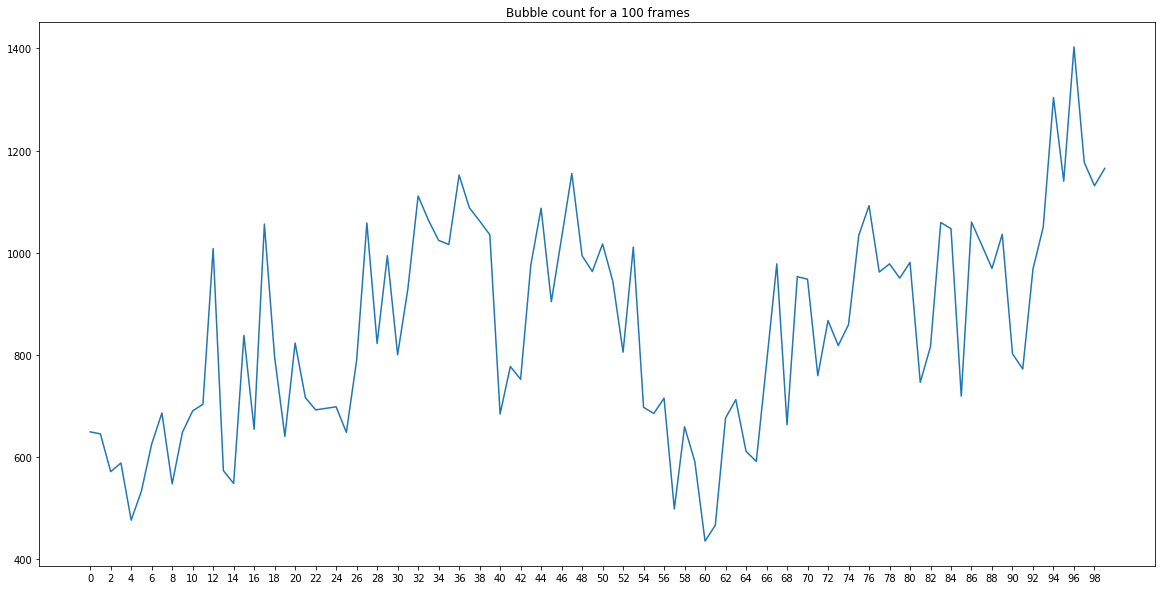

In [50]:
plt.figure(figsize=(20,10))
plt.plot(Bubble_number_list[100:200])
plt.title('Bubble count for a 100 frames')
x = np.arange(0, 100, 2)
plt.xticks(x)
plt.show()

In [13]:
size_img = (frame_height, frame_width)
# frames 111 and 112
frame111 = cap.set(cv2.CAP_PROP_POS_FRAMES, 111)
ret, frame111 = cap.read()
frame112 = cap.set(cv2.CAP_PROP_POS_FRAMES, 112)
ret, frame112 = cap.read()

total_number111, list_percentages111 = bubble_size_distribution(frame111, size_img, list_max_group_perimeters, list_max_group_areas, pixels_to_mm, display_results = True)
total_number112, list_percentages112 = bubble_size_distribution(frame112, size_img, list_max_group_perimeters, list_max_group_areas, pixels_to_mm, display_results = True)

In [14]:
(total_number111, total_number112)

(703, 1008)

In [16]:
# frame 165 and 166
frame165 = cap.set(cv2.CAP_PROP_POS_FRAMES, 165)
ret, frame165 = cap.read()
frame166 = cap.set(cv2.CAP_PROP_POS_FRAMES, 166)
ret, frame166 = cap.read()

total_number165, list_percentages165 = bubble_size_distribution(frame165, size_img, list_max_group_perimeters, list_max_group_areas, pixels_to_mm, display_results = True)
total_number166, list_percentages166 = bubble_size_distribution(frame166, size_img, list_max_group_perimeters, list_max_group_areas, pixels_to_mm, display_results = True)


In [17]:
total_number165, total_number166

(591, 783)

In [51]:
import pandas as pd
# perimeter list to dataframe
df_perimeters = pd.DataFrame(groups_list)

# rename the columns of the dataframe
df_perimeters.rename(columns={0: "Group1", 1: "Group2", 2: "Group3", 3: "Group4", }, inplace=True)

df_perimeters

,Group1,Group2,Group3,Group4
0,"{'perimeters': 807, 'areas': 984}","{'perimeters': 645, 'areas': 296}","{'perimeters': 48, 'areas': 162}","{'perimeters': 22, 'areas': 80}"
1,"{'perimeters': 469, 'areas': 616}","{'perimeters': 577, 'areas': 262}","{'perimeters': 77, 'areas': 171}","{'perimeters': 29, 'areas': 103}"
2,"{'perimeters': 458, 'areas': 581}","{'perimeters': 579, 'areas': 296}","{'perimeters': 78, 'areas': 158}","{'perimeters': 30, 'areas': 110}"
3,"{'perimeters': 445, 'areas': 570}","{'perimeters': 547, 'areas': 250}","{'perimeters': 68, 'areas': 166}","{'perimeters': 31, 'areas': 105}"
4,"{'perimeters': 274, 'areas': 341}","{'perimeters': 419, 'areas': 185}","{'perimeters': 73, 'areas': 144}","{'perimeters': 37, 'areas': 133}"
...,...,...,...,...
219,"{'perimeters': 225, 'areas': 334}","{'perimeters': 445, 'areas': 198}","{'perimeters': 88, 'areas': 134}","{'perimeters': 35, 'areas': 127}"
220,"{'perimeters': 551, 'areas': 712}","{'perimeters': 537, 'areas': 239}","{'perimeters': 52, 'areas': 133}","{'perimeters': 33, 'areas': 89}"
221,"{'perimeters': 258, 'areas': 349}","{'perimeters': 456, 'areas': 198}","{'perimeters': 84, 'areas': 154}","{'perimeters': 33, 'areas': 130}"
222,"{'perimeters': 736, 'areas': 897}","{'perimeters': 525, 'areas': 250}","{'perimeters': 46, 'areas': 112}","{'perimeters': 28, 'areas': 76}"


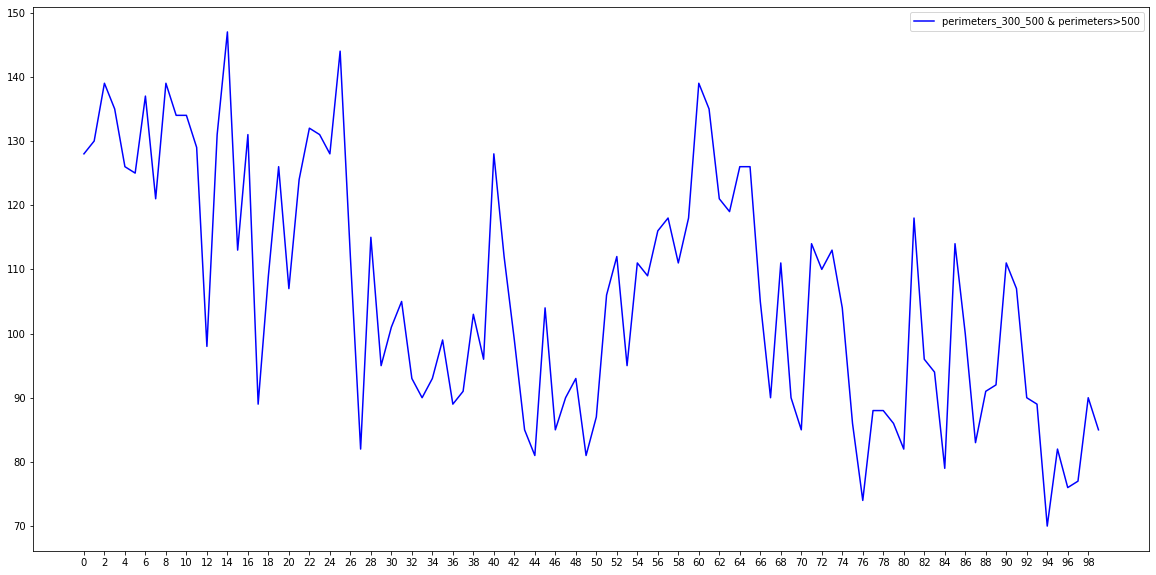

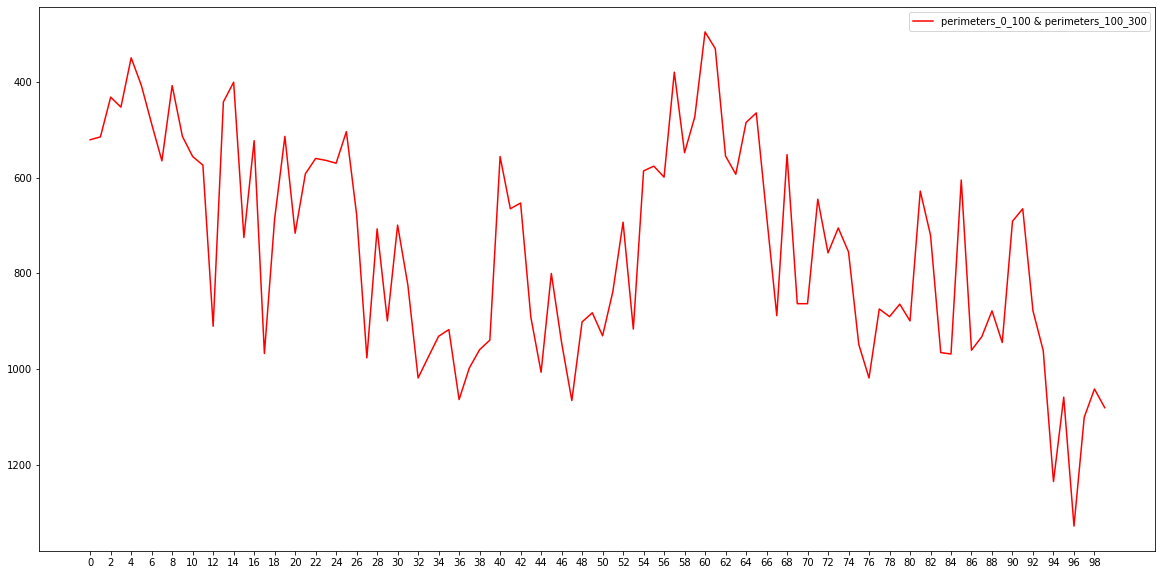

In [52]:
values_big = []
# plot perimeters>500 
for row1,row2 in zip(df_perimeters['Group3'],df_perimeters['Group4']):
    values_big.append(row1['perimeters'] + row2['perimeters'])
plt.figure(figsize=(20,10))
plt.xticks(np.arange(0, 100, 2))
plt.plot(values_big[100:200], color='blue')
plt.legend(['perimeters_300_500 & perimeters>500'])
plt.show()

velues_small = []
# plot perimeters_0_100
for row1 , row2 in zip(df_perimeters['Group1'],df_perimeters['Group2']):
    velues_small.append(row1['perimeters'] + row2['perimeters'])

plt.figure(figsize=(20,10))
# flip the y axis
plt.gca().invert_yaxis()
plt.xticks(np.arange(0, 100, 2))
plt.plot(velues_small[100:200], color='red')
plt.legend(['perimeters_0_100 & perimeters_100_300'])
plt.show()


In [18]:
list_percentages111, list_percentages112

([{'perimeters': 174, 'areas': 248},
  {'perimeters': 400, 'areas': 153},
  {'perimeters': 88, 'areas': 152},
  {'perimeters': 41, 'areas': 150}],
 [{'perimeters': 377, 'areas': 494},
  {'perimeters': 533, 'areas': 233},
  {'perimeters': 66, 'areas': 163},
  {'perimeters': 32, 'areas': 118}])

In [19]:
# frame 116 and 117
frame116 = cap.set(cv2.CAP_PROP_POS_FRAMES, 116)
ret, frame116 = cap.read()
frame117 = cap.set(cv2.CAP_PROP_POS_FRAMES, 117)
ret, frame117 = cap.read()

total_number116, list_percentages116 = bubble_size_distribution(frame116, size_img, list_max_group_perimeters, list_max_group_areas, pixels_to_mm, display_results = True)
total_number117, list_percentages117 = bubble_size_distribution(frame117, size_img, list_max_group_perimeters, list_max_group_areas, pixels_to_mm, display_results = True)


In [20]:
list_percentages116, list_percentages117

([{'perimeters': 167, 'areas': 228},
  {'perimeters': 356, 'areas': 127},
  {'perimeters': 89, 'areas': 146},
  {'perimeters': 42, 'areas': 153}],
 [{'perimeters': 420, 'areas': 558},
  {'perimeters': 547, 'areas': 232},
  {'perimeters': 66, 'areas': 165},
  {'perimeters': 23, 'areas': 101}])

: 

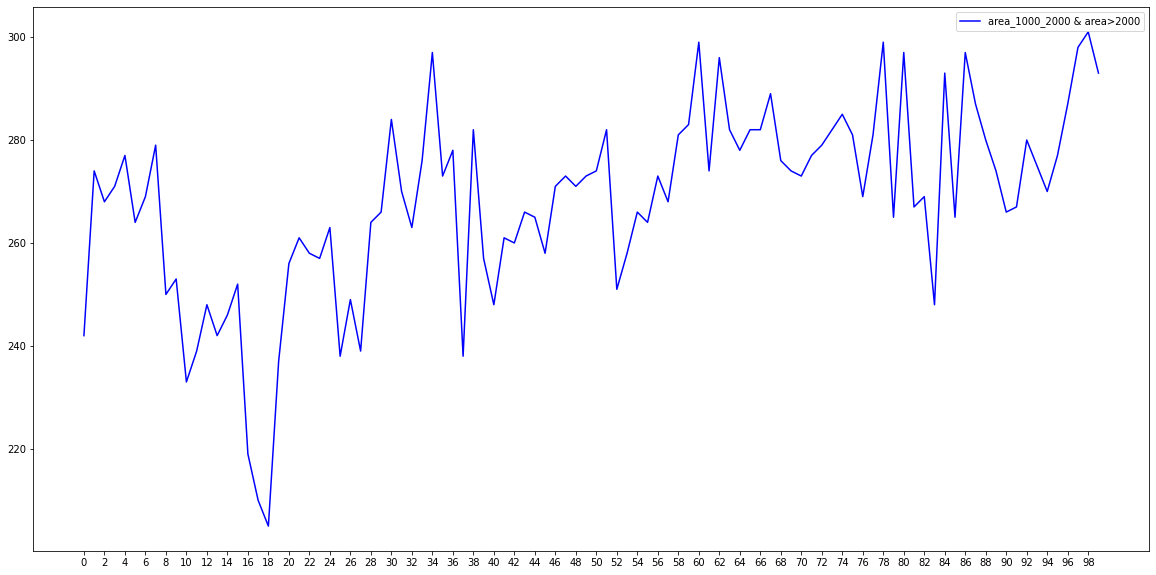

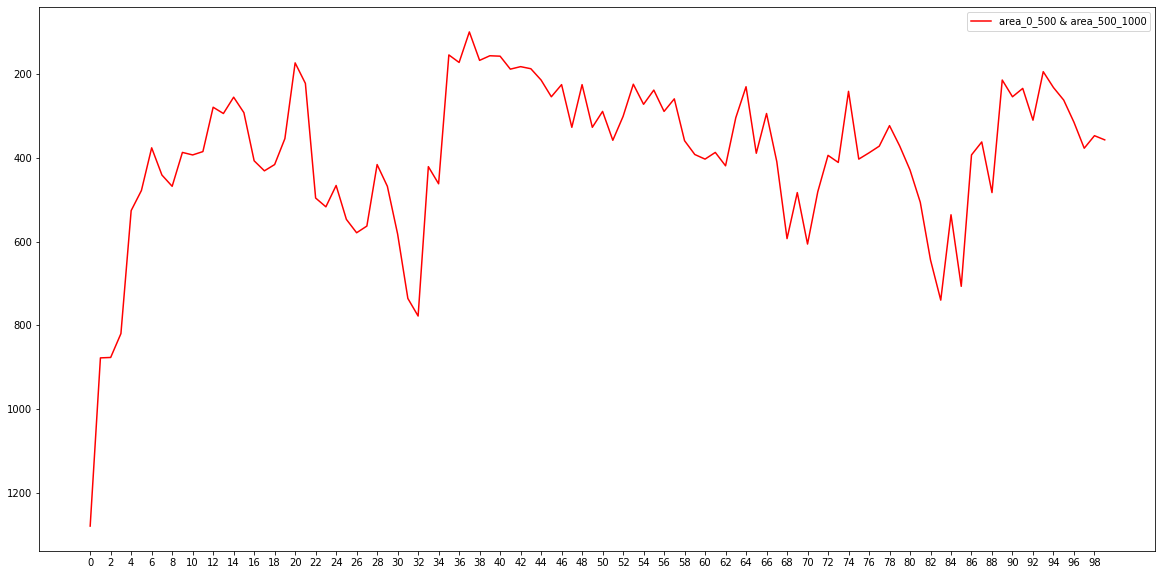

In [53]:
import matplotlib.pyplot as plt

values_big = []
# plot perimeters>500 
for row1,row2 in zip(df_perimeters['Group3'],df_perimeters['Group4']):
    values_big.append(row1['areas'] + row2['areas'])
plt.figure(figsize=(20,10))
plt.xticks(np.arange(0, 100, 2))
plt.plot(values_big[:100], color='blue')
plt.legend(['area_1000_2000 & area>2000'])
plt.show()

velues_small = []
# plot perimeters_0_100
for row1 , row2 in zip(df_perimeters['Group1'],df_perimeters['Group2']):
    velues_small.append(row1['areas'] + row2['areas'])

plt.figure(figsize=(20,10))
# flip the y axis
plt.gca().invert_yaxis()
plt.xticks(np.arange(0, 100, 2))
plt.plot(velues_small[:100], color='red')
plt.legend(['area_0_500 & area_500_1000'])
plt.show()

In [54]:
%reset

Nothing done.


: 